Importing the data

In [3]:
import pandas as pd
df = pd.read_csv("/Users/ahmadrezaie/2_My_papers/Synthetic_Data_Gen/data/input/TaskC-TrainingSet.csv")

In [2]:
df.head()

,dataset,encounter_id,dialogue,note
0,virtassist,D2N001,"[doctor] hi , martha . how are you ?\n[patient...",CHIEF COMPLAINT\n\nAnnual exam.\n\nHISTORY OF ...
1,virtassist,D2N002,"[doctor] hi , andrew , how are you ?\n[patient...",CHIEF COMPLAINT\n\nJoint pain.\n\nHISTORY OF P...
2,virtassist,D2N003,"[doctor] hi , john . how are you ?\n[patient] ...",CHIEF COMPLAINT\n\nBack pain.\n\nHISTORY OF PR...
3,virtassist,D2N004,"[doctor] hi , james , how are you ?\n[patient]...",CHIEF COMPLAINT\n\nBack pain.\n\nHISTORY OF PR...
4,virtassist,D2N005,"[doctor] hey , ms. hill . nice to see you .\n[...",CC:\n\nRight middle finger pain.\n\nHPI:\n\nMs...


In [14]:
df["dialogue"][0]

"[doctor] hi , martha . how are you ?\n[patient] i'm doing okay . how are you ?\n[doctor] i'm doing okay . so , i know the nurse told you about dax . i'd like to tell dax a little bit about you , okay ?\n[patient] okay .\n[doctor] martha is a 50-year-old female with a past medical history significant for congestive heart failure , depression and hypertension who presents for her annual exam . so , martha , it's been a year since i've seen you . how are you doing ?\n[patient] i'm doing well . i've been traveling a lot recently since things have , have gotten a bit lighter . and i got my , my vaccine , so i feel safer about traveling . i've been doing a lot of hiking . uh , went to washington last weekend to hike in northern cascades, like around the mount baker area .\n[doctor] nice . that's great . i'm glad to hear that you're staying active , you know . i , i just love this weather . i'm so happy the summer is over . i'm definitely more of a fall person .\n[patient] yes , fall foliage

**Loading and using transformers**

In [18]:
! pip install spacy


zsh:1: /Users/ahmadrezaie/2_My_papers/Synthetic_Data_Gen/.env/bin/pip: bad interpreter: /Users/ahmadrezaie/papers/Synthetic_Data_Gen/.env/bin/python: no such file or directory
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 422.0 kB/s eta 0:00:0000:0100:01
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.7.1
    Uninstalling pydantic-2.7.1:
      Successfully uninstalled pydantic-2.7.1


In [23]:
! pip install "/Users/ahmadrezaie/Downloads/en_core_sci_lg-0.5.4.tar.gz"


zsh:1: /Users/ahmadrezaie/2_My_papers/Synthetic_Data_Gen/.env/bin/pip: bad interpreter: /Users/ahmadrezaie/papers/Synthetic_Data_Gen/.env/bin/python: no such file or directory
Processing /Users/ahmadrezaie/Downloads/en_core_sci_lg-0.5.4.tar.gz
  Preparing metadata (setup.py) ... done
  Created wheel for en-core-sci-lg: filename=en_core_sci_lg-0.5.4-py3-none-any.whl size=531476539 sha256=ea796dadf8b2f1882c8ca7f360b9912078e500fc5f7ebb475c3e62d890431ed7
  Stored in directory: /Users/ahmadrezaie/Library/Caches/pip/wheels/fa/c3/cd/25e44b1351bd0857b3a26868aa582fe708d8cb5ac4f1140d23
Successfully built en-core-sci-lg
  Attempting uninstall: en-core-sci-lg
    Found existing installation: en-core-sci-lg 0.5.4
    Uninstalling en-core-sci-lg-0.5.4:
      Successfully uninstalled en-core-sci-lg-0.5.4


In [1]:
import spacy
nlp = spacy.load("en_core_sci_lg")

ModuleNotFoundError: No module named 'spacy'

In [ ]:
#! pip install transformers

In [4]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/Users/ahmadrezaie/2_My_papers/Synthetic_Data_Gen/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
# 1. Convert all entries in 'dialogue' to strings, replacing NaN with an empty string
df['dialogue'] = df['dialogue'].astype(str).fillna('')

# 2. Remove newline characters from the 'dialogue' column
df['dialogue'] = df['dialogue'].str.replace('\n', '')

In [5]:
df["dialogue"][0]

"[doctor] hi , martha . how are you ?\n[patient] i'm doing okay . how are you ?\n[doctor] i'm doing okay . so , i know the nurse told you about dax . i'd like to tell dax a little bit about you , okay ?\n[patient] okay .\n[doctor] martha is a 50-year-old female with a past medical history significant for congestive heart failure , depression and hypertension who presents for her annual exam . so , martha , it's been a year since i've seen you . how are you doing ?\n[patient] i'm doing well . i've been traveling a lot recently since things have , have gotten a bit lighter . and i got my , my vaccine , so i feel safer about traveling . i've been doing a lot of hiking . uh , went to washington last weekend to hike in northern cascades, like around the mount baker area .\n[doctor] nice . that's great . i'm glad to hear that you're staying active , you know . i , i just love this weather . i'm so happy the summer is over . i'm definitely more of a fall person .\n[patient] yes , fall foliage

**Calculating token avg for SOURCE with doctor and patient included**

In [9]:
# 3. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 4. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 5. Apply the token counting function to each row in 'dialogue'
df['token_count'] = df['dialogue'].apply(count_tokens)

# 6. Calculate the average token count
avg_token_count = df['token_count'].mean()

# Print the average token count
print(f"Average token count in 'dialogue': {avg_token_count}")


Average token count in 'dialogue': 1589.8507462686566


**Counting token avg for SOURCE without doctor and patient included**

In [2]:
# Assuming your dataset is already loaded into a DataFrame called df
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\check\\train.csv")
# 1. Convert all entries in 'dialogue' to strings, replacing NaN with an empty string
df['dialogue'] = df['dialogue'].astype(str).fillna('')

# 2. Remove newline characters from the 'dialogue' column
df['dialogue'] = df['dialogue'].str.replace('\n', '')

NameError: name 'pd' is not defined

In [10]:
import pandas as pd
from transformers import BertTokenizer
import re


# 3. Remove speaker tags like "[doctor]:" and "[patient]:"
def remove_speaker_tags(text):
    # Using regex to remove any pattern that matches "[doctor]:" or "[patient]:"
    cleaned_text = re.sub(r'\[doctor\]|\[patient\]', '', text, flags=re.IGNORECASE)
    return cleaned_text.strip()  # Strip any leading or trailing whitespace

df['dialogue'] = df['dialogue'].apply(remove_speaker_tags)

# 4. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 5. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 6. Apply the token counting function to each row in 'dialogue'
df['token_count'] = df['dialogue'].apply(count_tokens)

# 7. Calculate the average token count
avg_token_count = df['token_count'].mean()

# Print the average token count
print(f"Average token count in 'dialogue' after removing speaker tags: {avg_token_count}")


Average token count in 'dialogue' after removing speaker tags: 1422.6119402985075


**AVG token count for TARGET**

In [5]:
df["note"][0]

"CHIEF COMPLAINT\n\nAnnual exam.\n\nHISTORY OF PRESENT ILLNESS\n\nMartha Collins is a 50-year-old female with a past medical history significant for congestive heart failure, depression, and hypertension who presents for her annual exam. It has been a year since I last saw the patient.\n\nThe patient has been traveling a lot recently since things have gotten a bit better. She reports that she got her COVID-19 vaccine so she feels safer about traveling. She has been doing a lot of hiking.\n\nShe reports that she is staying active. She has continued watching her diet and she is doing well with that. The patient states that she is avoiding salty foods that she likes to eat. She has continued utilizing her medications. The patient denies any chest pain, shortness of breath, or swelling in her legs.\n\nRegarding her depression, she reports that she has been going to therapy every week for the past year. This has been really helpful for her. She denies suicidal or homicidal ideation.\n\nThe 

In [28]:
# 1. Convert all entries in 'note' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\check\\train.csv")
df['note'] = df['note'].astype(str).fillna('')

# 2. Remove newline characters from the 'dialogue' column
df['note'] = df['note'].str.replace('\n', '')
df['note'] = df['note'].str.replace('*', '')

In [29]:
df["note"][0]

"CHIEF COMPLAINTAnnual exam.HISTORY OF PRESENT ILLNESSMartha Collins is a 50-year-old female with a past medical history significant for congestive heart failure, depression, and hypertension who presents for her annual exam. It has been a year since I last saw the patient.The patient has been traveling a lot recently since things have gotten a bit better. She reports that she got her COVID-19 vaccine so she feels safer about traveling. She has been doing a lot of hiking.She reports that she is staying active. She has continued watching her diet and she is doing well with that. The patient states that she is avoiding salty foods that she likes to eat. She has continued utilizing her medications. The patient denies any chest pain, shortness of breath, or swelling in her legs.Regarding her depression, she reports that she has been going to therapy every week for the past year. This has been really helpful for her. She denies suicidal or homicidal ideation.The patient reports that she is 

In [11]:
# 3. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 4. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 5. Apply the token counting function to each row in 'dialogue'
df['token_count'] = df['note'].apply(count_tokens)

# 6. Calculate the average token count
avg_token_count = df['token_count'].mean()

# Print the average token count
print(f"Average token count in 'note': {avg_token_count}")

Average token count in 'note': 571.6268656716418


**AVG of sentences for TARGET**

In [31]:
# 1. Convert all entries in 'note' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\check\\train.csv")
df['note'] = df['note'].astype(str).fillna('')

# 2. Remove newline characters from the 'dialogue' column
df['note'] = df['note'].str.replace('\n', '')
df['note'] = df['note'].str.replace('*', '')

In [34]:
def count_sentences(text):
    # Split the text by sentence-ending punctuation (., ?, !)
    sentences = re.split(r'[.!?:]+', text)
    # Filter out empty strings that might result from splitting
    sentences = [s.strip() for s in sentences if s.strip()]
    return len(sentences)

# 4. Apply the sentence counting function to each row in 'note'
df['sentence_count'] = df['note'].apply(count_sentences)

# 5. Calculate the average sentence count
avg_sentence_count = df['sentence_count'].mean()

# Print the average sentence count
print(f"Average sentence count in 'note': {avg_sentence_count}")


Average sentence count in 'note': 49.52238805970149


**Calculating the size**

In [35]:
len(df)

67

**Calculating the frequency of SOURCE**

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# 1. Convert all entries in 'dialogue' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\check\\train.csv")
df['dialogue'] = df['dialogue'].astype(str).fillna('')

# 2. Remove newline characters from the 'dialogue' column
df['dialogue'] = df['dialogue'].str.replace('\n', '')

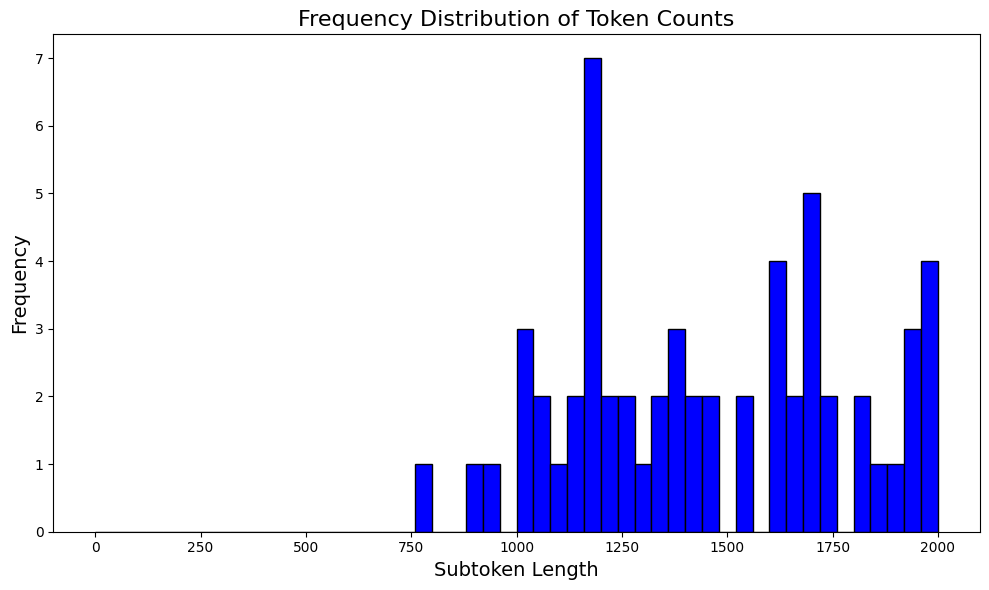

In [38]:
# 3. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 4. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 5. Apply the token counting function to each row in 'dialogue'
df['token_count'] = df['dialogue'].apply(count_tokens)

# 6. Plot the histogram of token counts
plt.figure(figsize=(10, 6))
plt.hist(df['token_count'], bins=50, range=(0, 2000), color='blue', edgecolor='black')

# 7. Set the title and labels
plt.title('Frequency Distribution of Token Counts', fontsize=16)
plt.xlabel('Subtoken Length', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# 8. Save the plot as an image
plt.tight_layout()
plt.savefig('token_count_histogram.png')

# 9. Show the plot
plt.show()

**Calculating the frequency of TARGET**

In [39]:
# 1. Convert all entries in 'note' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\check\\train.csv")
df['note'] = df['note'].astype(str).fillna('')

# 2. Remove newline characters from the 'dialogue' column
df['note'] = df['note'].str.replace('\n', '')
df['note'] = df['note'].str.replace('*', '')

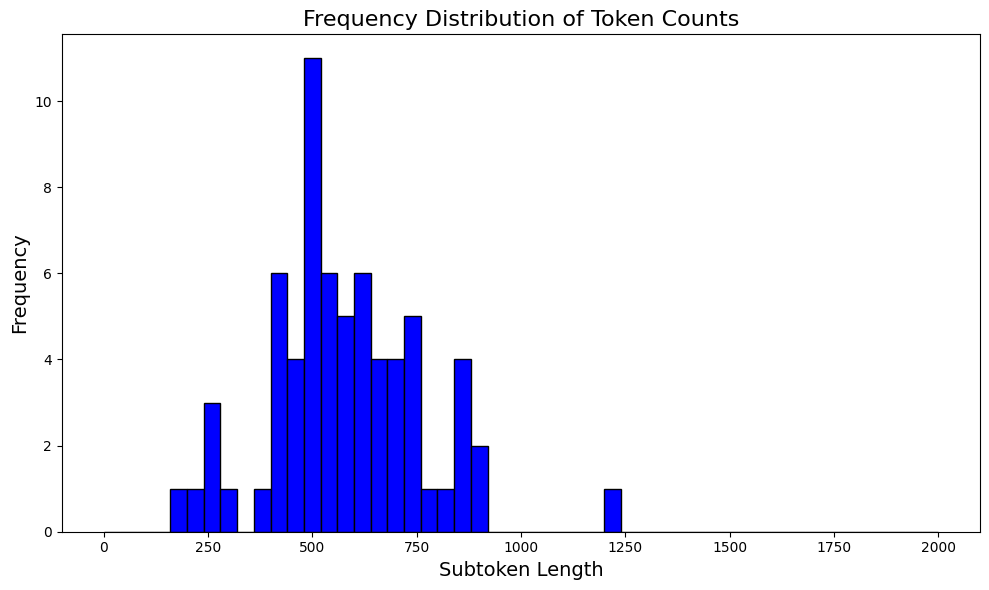

In [40]:
# 3. Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 4. Function to count tokens in a text
def count_tokens(text):
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# 5. Apply the token counting function to each row in 'dialogue'
df['token_count'] = df['note'].apply(count_tokens)

# 6. Plot the histogram of token counts
plt.figure(figsize=(10, 6))
plt.hist(df['token_count'], bins=50, range=(0, 2000), color='blue', edgecolor='black')

# 7. Set the title and labels
plt.title('Frequency Distribution of Token Counts', fontsize=16)
plt.xlabel('Subtoken Length', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# 8. Save the plot as an image
plt.tight_layout()
plt.savefig('token_count_histogram_for_TARGET.png')

# 9. Show the plot
plt.show()

**Calculate the avg of turns**

In [41]:
# 1. Convert all entries in 'dialogue' to strings, replacing NaN with an empty string
df = pd.read_csv("C:\\Users\\SAFIR2023\\Desktop\\check\\train.csv")
df['dialogue'] = df['dialogue'].astype(str).fillna('')

# 2. Function to count the number of turns in a dialog
def count_turns(text):
    # Split the text by speaker tags to identify turns
    turns = text.split('[')
    # Exclude any empty splits and count the rest
    num_turns = len([turn for turn in turns if turn.strip()])
    return num_turns

# 3. Apply the turn counting function to each row in 'dialogue'
df['turn_count'] = df['dialogue'].apply(count_turns)

# 4. Calculate the average number of turns per dialog
avg_turn_count = df['turn_count'].mean()

# 5. Print the average number of turns
print(f"Average number of turns per dialog: {avg_turn_count:.2f}")


Average number of turns per dialog: 55.75
